# Multi-GEOFF Experiment 3 — learning a good solution with online connectivity changes

Experiments 1 and 2 were analysis: can Autostep separate useful from useless connections (1), and
do the connection *maturity* stages mean what they are supposed to (2). This notebook is the first
that tries to **learn** a good solution — separate subnetworks and low loss — by changing the
network's connectivity while it trains.

The problem is 8-task non-stationary **multi-GEOFF** (`phd/jax_core/tasks/multi_geoff.py`): eight
independent GEOFF sub-networks with block-diagonal teacher connectivity, per-output squared error,
and one slot's readout columns permuted every 250 steps (each slot on average once every 2,000
steps, via `perturbation_period(2000, 8)`). Eight subtasks rather than Experiment 1's two, so the
gap between a good and a bad structure is wide.

### Contents

* **Baselines interlude.** Dense and block-sparse over a range of parameter counts. These replace
  the paper's Figure 4 numbers as reference points, and they set Experiment 3's **connection
  budget** — roughly the smallest parameter count at which block-sparse does well, and no more. The
  plan's "try a few meta step-sizes" reliability check is folded in here, at a reference budget.
* **3a — static initial structure.** The initialization held fixed. This is Experiment 3's own
  baseline and is expected to perform poorly.
* **3b — online connectivity changes.** Connections are pruned when judged useless and replaced
  one-for-one elsewhere, so the count never leaves the budget. Three versions in sequence: the
  **base** version (gradient masking, initial hidden→output connections protected), **Variant 1**
  (neither of those), and **Variant 2** (Variant 1 plus maturity-gated generation).

### Where the code lives

The algorithm — the network, the prune rule, generation and the separation metrics — is in
`dynamic_masked_mlp.py`, with tests in `../tests/test_multi_geoff_dynamic_mlp.py`. The **stage rule
is imported from Experiment 2's `connection_stages.py`** rather than reimplemented, so if that
experiment's validation revises the thresholds, Variant 2 follows without a code change here. This
notebook holds the experiment: the training scan, the sweeps, and the figures.

Read the module docstring first; in particular an output unit's incoming weights (skip *and*
hidden) live in one row of `w2`, because every per-unit quantity in the algorithm — Autostep's
effective-step-size normalizer, the squared-error trace v, the occupancy c, and every threshold
derived from them — is a row reduction over exactly that set.

### Settings inherited from Experiments 1 and 2

* **Autostep Variant B** (`version='squared_inputs'`) everywhere — the squared source-unit value as
  the curvature term. Experiment 1 settled on it.
* **Initial step-size 1e-6** for every connection, including generated ones. Never swept.
* **L1 0.01 in the subgradient form**, added to the gradient Autostep consumes, on every Experiment
  3 run. Experiment 1 found it extremely useful and the coefficient is a rule of thumb from the
  problem parameters, not a hyperparameter.
* Runs are cached: each configuration is one **mlflow-sweeper** sweep, so re-executing the notebook
  reloads metrics instead of retraining. Per-snapshot structure metrics go to `.npz` next to them.

In [1]:
import logging
import os
import sys
from dataclasses import dataclass

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optax
import pandas as pd
import seaborn as sns
from omegaconf import OmegaConf

from mlflow_sweeper import SweepConfig, run_sweep, delete_sweep

from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask, perturbation_period
from phd.jax_core.utils import stack_pytrees
from phd.research_utils.scripts.mlflow_download import download_experiment
from phd.research_utils.analysis.analysis_utils import load_experiment_data, get_color_palette
from phd.structure_search.block_sparse_mlp import compute_hidden_dim_for_params

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from masked_mlp import slot_ids
from dynamic_masked_mlp import (
    GROWTH, MATURE, NASCENT, STAGE_NAMES, DynamicAutostepMLP, block_sparse_skip_masks,
    dense_skip_masks, initial_structure, n_connections, structure_metrics,
)
from experiment_logging import (
    ci_halfwidth, load_traces, log_curves, plot_learning_curve, save_traces, summarize_runs,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Sweep state and metrics go to the **shared PostgreSQL mlflow-sweeper server** by default, read from
the `MLFLOW_TRACKING_URI` / `OPTUNA_TRACKING_URI` environment variables; set `USE_LOCAL_STORES` to
fall back to sqlite files next to this notebook. The env vars are only ever *read*, so this notebook
cannot repoint the session's tracking server.

**`NUM_STEPS` is tied to `INIT_LR`.** At an initial step-size of 1e-6 the step-sizes need millions
of steps to grow to a useful scale — Experiment 1 measured that at 1M steps its two Autostep
variants were still numerically indistinguishable, and used 3M. Experiment 3 needs *more* than that
in principle, because pruning cannot begin until weights are moving enough to cross zero, so 3M is
the floor rather than a comfortable margin. It is also the dominant cost knob: the whole notebook is
roughly linear in it.

**Seeds are nearly free, steps are not.** Every run is a `jax.lax.scan` over a small network, so it
is latency-bound on the sequential scan, not throughput-bound on the GPU (Experiment 1 measured 3M
steps at 75.6 s for 10 seeds vs 78.6 s for 30). Widen `N_MAIN_SEEDS` before shortening anything.

**Budget about three hours for the first execution**, then nothing on later ones. Measured at the
1920-connection scale with 10 seeds: 103 us/step without restructuring and 175 us/step with it, so
3M steps is roughly 5 and 9 minutes respectively, times 10 meta step-size runs, 12 baseline points
(the largest of which are slower), 3 static runs and 3 dynamic ones. `PARAM_GRID` is the cheapest
thing to trim if that is too much — the two ends of it carry the shape of the curve.

In [2]:
EXPERIMENT = 'multi-geoff-experiment-3'
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')
SWEEP_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'sweep_output')
OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'output')      # only used by the local-store fallback

# sqlite will not create a missing parent directory; it fails with "unable to open database file".
for _dir in (DATA_DIR, SWEEP_OUTPUT_DIR, OUTPUT_DIR):
    os.makedirs(_dir, exist_ok=True)

USE_LOCAL_STORES = False

if USE_LOCAL_STORES:
    MLFLOW_URI = f"sqlite:///{os.path.join(OUTPUT_DIR, 'mlruns.db')}"
    OPTUNA_URI = f"sqlite:///{os.path.join(OUTPUT_DIR, 'optuna.db')}"
else:
    MLFLOW_URI = os.environ.get(
        'MLFLOW_TRACKING_URI', f"sqlite:///{os.path.join(OUTPUT_DIR, 'mlruns.db')}")
    OPTUNA_URI = os.environ.get(
        'OPTUNA_TRACKING_URI', f"sqlite:///{os.path.join(OUTPUT_DIR, 'optuna.db')}")

mlflow.set_tracking_uri(MLFLOW_URI)

# --- Problem (multi-GEOFF defaults, non-stationary, 8 subtasks) ---
N_TASKS = 8
N_FEATURES_PER_TASK = 20
N_OUTPUTS_PER_TASK = 10
NOISE_STD = 1.0
PER_TASK_PERTURB_PERIOD = 2000
PERTURB_PERIOD = perturbation_period(PER_TASK_PERTURB_PERIOD, N_TASKS)   # -> 250

N_FEATURES = N_TASKS * N_FEATURES_PER_TASK      # 160
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK        # 80
INPUT_TASK_IDS = slot_ids(N_TASKS, N_FEATURES_PER_TASK)
OUTPUT_TASK_IDS = slot_ids(N_TASKS, N_OUTPUTS_PER_TASK)

# --- Learner ---
N_HIDDEN = 64            # total hidden units in every Experiment 3 network
ACTIVATION = 'leaky_relu'
INIT_LR = 1e-6           # fixed everywhere, never swept
L1_COEFF = 0.01          # subgradient L1 on all Experiment 3 runs; not a hyperparameter
GEN_CAP = 256            # connections generated per step at most; see the deficit check in 3b

# Experiment 1 chose 0.02 by the plan's rule (no divergence, then best performance) on the 2-task
# problem. The reliability check below re-runs the grid on *this* problem, where the effective
# step-size argument bites harder — 8 subtasks means denser credit assignment per output.
META_LR_EXP1 = 0.02
META_LR_GRID = [0.002, 0.005, 0.01, 0.02, 0.05]

# --- Baselines interlude ---
# Parameter counts to sweep, as connection counts. Block-sparse spends 30 connections per hidden
# unit per task and dense 240 per hidden unit, so both are exactly representable at every point.
PARAM_GRID = [240, 480, 960, 1920, 3840, 7680]
REFERENCE_PARAMS = 1920      # where the meta step-size grid is run: 64 hidden units block-sparse
BUDGET_TOLERANCE = 0.02      # "performs well" = within this much FVE of block-sparse's best

# --- Training / logging ---
NUM_STEPS = 3_000_000
BATCH_SIZE = 1           # online; also required, `generate_batch` asserts batch_size <= period
N_SNAPSHOTS = 250        # structure snapshots per run
N_LOG_POINTS = 250       # binned points logged for the per-step series
N_SWEEP_SEEDS = 10       # seeds per configuration of a multi-point sweep
N_MAIN_SEEDS = 20        # seeds for the 3a / 3b runs
N_SWEEP_JOBS = 1         # concurrent trials; see the note in Experiment 1 on why 1
FINAL_FRACTION = 0.1     # the plan's evaluation window: the last 10% of steps
BASE_SEED = 0

# Per-output MSE reference points. The irreducible MSE is `noise_std**2 = 1` exactly; the mean
# predictor sits at MSE 2 (FVE 0) in expectation over teachers, so treat that line as approximate
# per seed but a fine convergence threshold across 10+ seeds.
IRREDUCIBLE_MSE = NOISE_STD ** 2
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0

STRUCTURE_KEYS = ('connectivity_separation', 'signal_separation', 'hidden_input_purity',
                  'hidden_incoming', 'hidden_outgoing', 'dead_hidden_fraction', 'n_connections')

BASE_SWEEP_CONFIG = {
    'experiment': EXPERIMENT,
    'optuna_storage': OPTUNA_URI,
    'mlflow_storage': MLFLOW_URI,
    'output_dir': SWEEP_OUTPUT_DIR,
    'algorithm': 'grid',
    'spec': {'direction': 'minimize', 'metric': 'final_loss'},
}
print('MLflow store        :', MLFLOW_URI)
print('Optuna store        :', OPTUNA_URI)
print('Perturbation period :', PERTURB_PERIOD, 'steps (global)')
print('Mean-predictor MSE  :', BASELINE_MSE, ' | irreducible MSE:', IRREDUCIBLE_MSE)

INFO:2026-07-31 12:54:13,621:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


MLflow store        : postgresql:///mlflow?host=/var/run/postgresql&port=5433
Optuna store        : postgresql:///optuna?host=/var/run/postgresql&port=5433
Perturbation period : 250 steps (global)
Mean-predictor MSE  : 2.0  | irreducible MSE: 1.0


## Structures

Three families, all in the module's `[inputs | hidden]` output-layer layout:

| family | used by | shape |
|---|---|---|
| `block_sparse` | baselines | each hidden unit fully connected to its own task's inputs and outputs |
| `dense` | baselines | fully connected, no skip connections |
| `exp3` | 3a and 3b | one random output per hidden unit, then the rest of the budget split evenly over all hidden and output units as random input connections (skips for the output units) |

The `exp3` structure is redrawn per seed rather than fixed once, so nothing downstream rests on one
lucky draw. `structure_fn` returns `(masks, protected)`, where `protected` is the initial
hidden→output set that 3b's base version treats specially — the only connections carrying gradient
into the hidden layer, and the only ones exempt from pruning.

In [3]:
def baseline_hidden(kind, target_params):
    """Hidden-unit count that hits a parameter budget, per `compute_hidden_dim_for_params`."""
    per_unit = compute_hidden_dim_for_params(
        target_params, kind, 2, N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK)
    return per_unit * N_TASKS if kind == 'block_sparse' else per_unit


def structure_fn(kind, target_params):
    """`key -> (masks, protected)` for one structure family at one parameter count.

    The baselines ignore the key (their structure is deterministic); `exp3` draws a fresh one per
    seed. `protected` is None except for `exp3`, which is the only family with a distinguished set
    of initial hidden->output connections.
    """
    if kind == 'exp3':
        return lambda key: initial_structure(
            N_FEATURES, N_HIDDEN, N_OUTPUTS, target_params, key)
    n_hidden = baseline_hidden(kind, target_params)
    if kind == 'block_sparse':
        masks, _ = block_sparse_skip_masks(
            N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK, n_hidden)
    elif kind == 'dense':
        masks = dense_skip_masks(N_FEATURES, n_hidden, N_OUTPUTS)
    else:
        raise ValueError(f'Unknown structure kind: {kind}!')
    return lambda key: (masks, None)


for kind in ('block_sparse', 'dense'):
    sizes = [(p, baseline_hidden(kind, p), n_connections(structure_fn(kind, p)(None)[0]))
             for p in PARAM_GRID]
    print(f'{kind:13s}' + '  '.join(f'{p}->{h}h/{c}c' for p, h, c in sizes))
_masks, _protected = structure_fn('exp3', REFERENCE_PARAMS)(jax.random.PRNGKey(BASE_SEED))
print(f'exp3         {REFERENCE_PARAMS} connections requested, {n_connections(_masks)} placed; '
      f'{int(_protected.sum())} protected hidden->output; '
      f'{float(_masks["w1"].sum()) / N_HIDDEN:.1f} inputs per hidden unit')

block_sparse 240->8h/240c  480->16h/480c  960->32h/960c  1920->64h/1920c  3840->128h/3840c  7680->256h/7680c
dense        240->1h/240c  480->2h/480c  960->4h/960c  1920->8h/1920c  3840->16h/3840c  7680->32h/7680c
exp3         1920 connections requested, 1920 placed; 64 protected hidden->output; 12.9 inputs per hidden unit


## Run machinery

`run_phase` is a **nested scan**: an inner scan emitting only per-step scalars, wrapped in an outer
scan that emits one structure snapshot per block. A snapshot is a handful of scalars
(`structure_metrics`), so 250 of them cost nothing, while the per-step record is just the loss and
the restructuring counts.

The restructuring counts are what make the connection budget auditable. Every step reports how many
connections it pruned and generated, plus the running `deficit` — the shortfall when two generation
proposals collide on the same pathway or `GEN_CAP` saturates. The number of connections is *exactly*
`budget - deficit` at every step, so a deficit that does not sit near zero means the budget is not
being honoured. The 3b section checks it explicitly rather than trusting it.

In [4]:
def build_tasks(n_seeds, base_seed=BASE_SEED):
    """One independent teacher per seed, stacked for `vmap`."""
    return stack_pytrees([
        MultiGEOFFTask(
            N_TASKS, perturb_period=PERTURB_PERIOD,
            n_features_per_task=N_FEATURES_PER_TASK, n_outputs_per_task=N_OUTPUTS_PER_TASK,
            noise_std=NOISE_STD, seed=base_seed + s,
        ) for s in range(n_seeds)
    ])


def run_phase(learner, task, n_steps, n_snapshots=N_SNAPSHOTS):
    """`n_steps` of online training, emitting the per-step loss and `n_snapshots` snapshots."""
    inner_steps = n_steps // n_snapshots
    assert inner_steps > 0 and inner_steps * n_snapshots == n_steps, \
        f"n_steps ({n_steps}) must be a multiple of n_snapshots ({n_snapshots})!"

    def inner_step(carry, _):
        learner, task = carry
        task, (x, y) = task.generate_batch(BATCH_SIZE)
        learner, info = learner.step(x[0], y[0])
        return (learner, task), info

    def outer_step(carry, _):
        # Snapshots are taken at the end of each block, so the last one is the final state.
        carry, info = jax.lax.scan(inner_step, carry, length=inner_steps)
        learner = carry[0]
        snapshot = {
            **structure_metrics(learner.model, INPUT_TASK_IDS, OUTPUT_TASK_IDS,
                                learner.stages, n_tasks=N_TASKS),
            # Per-block restructuring summary, expressed per step so blocks of different lengths
            # stay comparable.
            'prune_rate': info['n_pruned'].mean(),
            'generate_rate': info['n_generated'].mean(),
            'deficit': info['deficit'].mean(),
            'max_deficit': info['deficit'].max(),
        }
        return carry, (info['loss'], snapshot)

    carry, (losses, snaps) = jax.lax.scan(outer_step, (learner, task), length=n_snapshots)
    return carry, losses.reshape(-1), snaps


def run_config(structure, meta_lr, n_seeds, n_steps=NUM_STEPS, *, l1=0.0, restructure=False,
               protect=False, require_mature_source=False):
    """Train one configuration for `n_seeds` seeds in parallel, returning the raw result arrays.

    Args:
        structure: `key -> (masks, protected)`, from `structure_fn`
        meta_lr: Autostep meta step-size
        n_seeds: Seeds, batched with `vmap` (nearly free; see the configuration note)
        n_steps: Training steps
        l1: L1 coefficient (0 for the baselines, `L1_COEFF` for every Experiment 3 run)
        restructure: Prune and generate online (3b)
        protect: Treat the initial hidden->output connections as 3b's base version does — the only
            ones carrying gradient into the hidden layer, and exempt from pruning
        require_mature_source: 3b Variant 2's maturity gate on generation
    """
    tasks = build_tasks(n_seeds)

    def one_seed(key, task):
        structure_key, weight_key = jax.random.split(key)
        masks, protected = structure(structure_key)
        learner = DynamicAutostepMLP.init(
            masks, meta_lr, weight_key, init_lr=INIT_LR, l1=l1, activation=ACTIVATION,
            restructure=restructure, gen_cap=GEN_CAP,
            require_mature_source=require_mature_source,
            protected=protected if protect else None)
        _, losses, snaps = run_phase(learner, task, n_steps)
        return losses, snaps

    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    losses, snaps = jax.jit(jax.vmap(one_seed))(keys, tasks)
    return {'losses': losses, **snaps}


def snapshot_steps(n_steps, n_snapshots=N_SNAPSHOTS):
    """Step index each snapshot was taken at (the end of its block)."""
    return np.arange(1, n_snapshots + 1) * (n_steps // n_snapshots)


def per_output_mse(losses):
    """The loss is summed over outputs; every reference point is defined per output."""
    return np.asarray(losses) / N_OUTPUTS


def fve(mse):
    """Fraction of explainable variance explained: 1 for an optimal predictor, 0 for the mean."""
    return 1.0 - (np.asarray(mse) - IRREDUCIBLE_MSE)

## Sweep infrastructure

The same pattern as Experiment 1. `ExpSpec` records a run — the function that executes it and the
label used in plots — and `run_spec_sweep` turns a grid into a programmatic mlflow-sweeper sweep
whose objective logs the binned per-step series (`loss`, `fve`) and caches the per-snapshot
structure metrics to `.npz`. `allow_param_change=True` lets an edited grid update a sweep in place:
matching trials are migrated and only new grid points run.

Step counts and seed counts are sweep *parameters*, not closure variables, so changing `NUM_STEPS`
cannot leave a study looking complete and silently serve results computed at the old length.

In [5]:
@dataclass
class ExpSpec:
    name: str                  # mlflow sweep_name
    label: str                 # human-readable label for plots
    fn: callable               # (n_seeds, **swept hyperparameters) -> dict of result arrays
    cache_traces: bool = True  # False for multi-point grids, whose runs would overwrite each other


def log_result(result, n_steps, sweep_name, cache_traces):
    """Log a run's per-step curves, cache its snapshots, return the objective (final MSE)."""
    mse = per_output_mse(result['losses'])
    series = {'loss': mse, 'fve': fve(mse)}

    if cache_traces:
        # Snapshot arrays only — the per-step losses are already logged in binned form.
        save_traces(DATA_DIR, sweep_name,
                    **{k: np.asarray(v) for k, v in result.items() if k != 'losses'},
                    log_steps=snapshot_steps(n_steps))

    return log_curves(series, n_log_points=N_LOG_POINTS, final_fraction=FINAL_FRACTION,
                      objective_key='loss')


def _cast(name, value):
    """Sweep parameters arrive as floats; counts must stay ints (scan lengths, array shapes)."""
    return int(value) if name.startswith('n_') or name.endswith('params') else float(value)


def make_objective(spec):
    def objective(**params):
        kwargs = {k: _cast(k, v) for k, v in params.items()}
        return log_result(spec.fn(**kwargs), kwargs['n_steps'], spec.name, spec.cache_traces)
    return objective


def run_spec_sweep(spec, grid, n_seeds, n_steps=NUM_STEPS, n_jobs=N_SWEEP_JOBS, overwrite=False):
    params = {**grid, 'n_seeds': int(n_seeds), 'n_steps': int(n_steps)}
    cfg = {**BASE_SWEEP_CONFIG, 'sweep_name': spec.name, 'parameters': params}
    config = SweepConfig.from_dict_config(OmegaConf.create(cfg))
    # End any lingering active run so re-running a complete sweep does not raise "already active".
    if mlflow.active_run() is not None:
        mlflow.end_run()
    if overwrite:
        delete_sweep(config)
    # executor='thread' is required: the objective is a closure and the process pool rejects
    # anything that is not a top-level picklable function.
    run_sweep(config, make_objective(spec), n_jobs=n_jobs, log_params=True,
              no_plots=True, allow_param_change=True, executor='thread')


# `download_experiment` sanitizes spaces and dashes to underscores when naming its output
# (mlflow_download.py:269), so derive the CSV paths the same way.
_CSV_STEM = EXPERIMENT.replace(' ', '_').replace('-', '_')
PARAMS_CSV = os.path.join(DATA_DIR, f'{_CSV_STEM}_params.csv')
METRICS_CSV = os.path.join(DATA_DIR, f'{_CSV_STEM}_metrics.csv')
RUN_COUNT_MARKER = os.path.join(DATA_DIR, f'.{_CSV_STEM}_run_count')


def _n_finished_runs():
    """Number of finished MLflow runs in the experiment (cheap; no metric history)."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(EXPERIMENT)
    if exp is None:
        return 0
    return len(client.search_runs([exp.experiment_id],
                                  filter_string="attributes.status = 'FINISHED'",
                                  max_results=50000))


def load_sweep_data(force_download=False):
    """Load the experiment's CSVs, downloading from MLflow only when new runs have appeared."""
    n_runs = _n_finished_runs()
    cached = os.path.exists(PARAMS_CSV) and os.path.exists(METRICS_CSV)
    marker = None
    if os.path.exists(RUN_COUNT_MARKER):
        with open(RUN_COUNT_MARKER) as f:
            marker = f.read().strip()

    if force_download or not cached or marker != str(n_runs):
        download_experiment(EXPERIMENT, DATA_DIR, tracking_uri=MLFLOW_URI)
        with open(RUN_COUNT_MARKER, 'w') as f:
            f.write(str(n_runs))

    return load_experiment_data(PARAMS_CSV, METRICS_CSV)

## Plot helpers

Two shapes recur: a per-step series read back from MLflow (`plot_learning_curve`, imported from
`experiment_logging`), and a per-snapshot structure metric read from the cached `.npz`. The latter
gets `plot_snapshot_metric` below — mean over seeds with a confidence interval, since a structure
metric averaged over 20 independent draws is the quantity of interest, not any single run's.

In [6]:
def plot_snapshot_metric(traces_by_label, key, ylabel, ax=None, colors=None, hline=None,
                         hline_label=None, show_ci=True):
    """One line per run of a per-snapshot metric, mean over seeds with a `CI_LEVEL` band."""
    ax = ax or plt.gca()
    colors = colors or get_color_palette(n=len(traces_by_label))
    for color, (label, traces) in zip(colors, traces_by_label.items()):
        if traces is None or key not in traces:
            continue
        values = np.asarray(traces[key], dtype=np.float64)
        mean = np.nanmean(values, axis=0)
        ax.plot(traces['log_steps'], mean, color=color, label=label)
        if show_ci and values.shape[0] > 1:
            band = ci_halfwidth(np.nanstd(values, axis=0), values.shape[0])
            ax.fill_between(traces['log_steps'], mean - band, mean + band, color=color, alpha=0.2)
    if hline is not None:
        ax.axhline(hline, ls='--', c='gray', lw=1, label=hline_label)
    ax.set_xlabel('step')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.4)
    return ax


def final_value(traces, key, tail=0.1):
    """Mean of a snapshot metric over the last `tail` of the run, averaged over seeds."""
    values = np.asarray(traces[key], dtype=np.float64)
    return float(np.nanmean(values[:, -max(1, int(tail * values.shape[1])):]))


def summary_row(label, traces, runs=None, sweep_name=None):
    """One row of the cross-run comparison table."""
    row = {'run': label}
    if runs is not None and sweep_name is not None:
        rdf = runs[sweep_name].dropna(subset=['loss'])
        tail = rdf[rdf['step'] >= rdf['step'].max() * (1 - FINAL_FRACTION)]
        row['MSE'] = tail['loss'].mean()
        row['FVE'] = float(fve(tail['loss'].mean()))
    row.update({
        'conn. sep.': final_value(traces, 'connectivity_separation'),
        'signal sep.': final_value(traces, 'signal_separation'),
        'purity': final_value(traces, 'hidden_input_purity'),
        'in/hidden': final_value(traces, 'hidden_incoming'),
        'out/hidden': final_value(traces, 'hidden_outgoing'),
        'dead hidden': final_value(traces, 'dead_hidden_fraction'),
        'connections': final_value(traces, 'n_connections'),
        'prunes/step': final_value(traces, 'prune_rate'),
    })
    return row

# Baselines interlude — dense and block-sparse on 8-task multi-GEOFF

The problem changed from multi-MNIST, so there are no baseline numbers to inherit. These runs
produce them, and they fix Experiment 3's connection budget.

## Step 1 — meta step-size reliability check

One reliable global meta step-size is used everywhere. Experiment 1 chose 0.02 on the 2-task
problem; the grid is re-run here on the 8-task problem, for both dense and block-sparse at
`REFERENCE_PARAMS`, because 8 subtasks per output is where the effective step-size argument bites.
The hard requirement from the plan is that **no runs diverge**; among the values that satisfy that,
take the one that learns best.

In [7]:
META_LR_SPECS = {
    kind: ExpSpec(name=f'meta_lr_{kind}', label=kind.replace('_', '-'),
                  fn=lambda n_seeds, n_steps, meta_lr, _k=kind: run_config(
                      structure_fn(_k, REFERENCE_PARAMS), meta_lr, n_seeds, n_steps),
                  cache_traces=False)
    for kind in ('block_sparse', 'dense')
}

for spec in META_LR_SPECS.values():
    run_spec_sweep(spec, {'meta_lr': META_LR_GRID}, N_SWEEP_SEEDS)

cfgs, runs = load_sweep_data()

[I 2026-07-31 12:54:19,714] Using an existing study with name 'multi-geoff-experiment-3/meta_lr_block_sparse' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 5b679524aba64a6994afadc775eb4ea8.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.
[I 2026-07-31 12:54:20,270] Using an existing study with name 'multi-geoff-experiment-3/meta_lr_dense' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 029e5b45dd4e43a5bad9ecea25dad057.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


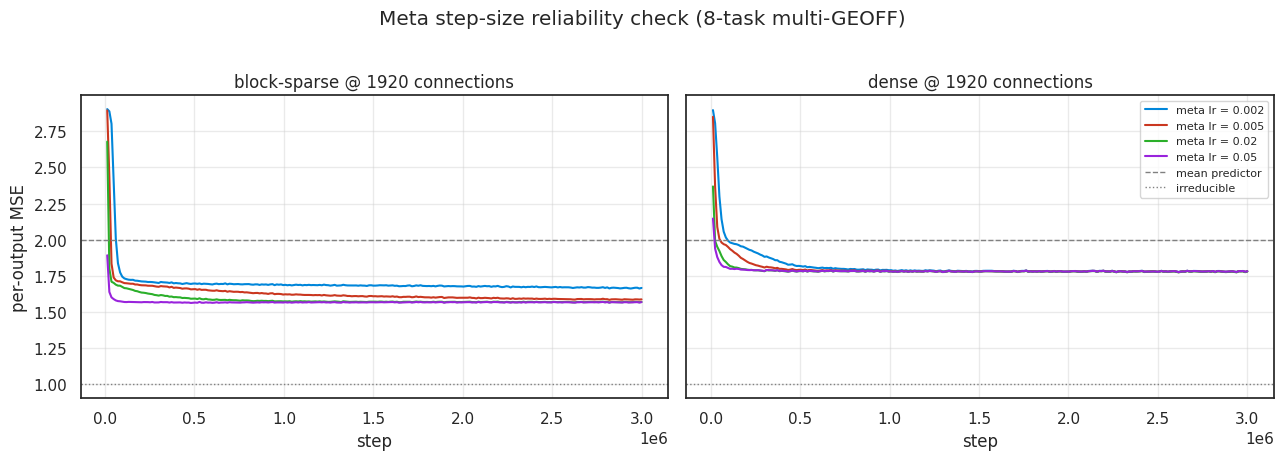

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
colors = get_color_palette(n=len(META_LR_GRID))
for ax, spec in zip(axes, META_LR_SPECS.values()):
    rdf = runs[spec.name].merge(cfgs[spec.name][['run_id', 'meta_lr']], on='run_id', how='left')
    for color, meta_lr in zip(colors, sorted(rdf['meta_lr'].astype(float).unique())):
        curve = (rdf[rdf['meta_lr'].astype(float) == meta_lr].dropna(subset=['loss'])
                 .groupby('step')['loss'].mean().sort_index())
        ax.plot(curve.index, curve.values, color=color, label=f'meta lr = {meta_lr:g}')
    ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
    ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible')
    ax.set_xlabel('step')
    ax.set_title(f'{spec.label} @ {REFERENCE_PARAMS} connections')
    ax.grid(True, alpha=0.4)
axes[0].set_ylabel('per-output MSE')
axes[-1].legend(fontsize=8)
plt.suptitle('Meta step-size reliability check (8-task multi-GEOFF)', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
def pick_meta_lr(n_std=2.0):
    """Best meta step-size that is reliable under *both* baseline structures.

    Reliable means the final MSE is finite (a diverged seed propagates as NaN through the
    across-seed mean, so divergence shows up as a missing value) and the final MSE plus `n_std`
    across-seed standard deviations still clears the mean predictor — so a configuration whose
    average only looks fine because some seeds are unstable is disqualified rather than averaged.
    """
    per_kind = {}
    for kind, spec in META_LR_SPECS.items():
        summary = summarize_runs(cfgs, runs, spec.name, ['meta_lr'], FINAL_FRACTION, BASELINE_MSE)
        summary['reliable'] = summary['converged'] & (
            summary['value'] + n_std * summary['value_std'].fillna(0.0) < BASELINE_MSE)
        per_kind[kind] = summary.set_index('meta_lr')

    shared = set.intersection(*[set(s.index[s['reliable']]) for s in per_kind.values()])
    if not shared:
        # Degrade rather than abort, so an unattended run still produces the figures below — each
        # fallback is louder than the last, and anything past the first makes the choice provisional.
        shared = set.intersection(*[set(s.index[s['converged']]) for s in per_kind.values()])
        print('WARNING: no meta step-size passed the strict reliability rule '
              f'(final MSE + {n_std} sd below the mean predictor). Falling back to the plain '
              'convergence rule; treat the choice below as provisional.')
    if not shared:
        print('WARNING: nothing converged under both structures at all — every configuration ended '
              'at or above the mean predictor. Falling back to Experiment 1\'s value. Read the '
              'learning curves above before trusting anything below: either the runs are too short '
              'for a 1e-6 initial step-size, or dense at this budget simply cannot learn the '
              '8-task problem, and the two look identical here.')
        return float(META_LR_EXP1), {}, per_kind
    worst = {m: max(s.loc[m, 'value'] for s in per_kind.values()) for m in shared}
    return float(min(worst, key=worst.get)), worst, per_kind


META_LR, worst_case, meta_lr_summaries = pick_meta_lr()
for kind, summary in meta_lr_summaries.items():
    print(kind)
    print(summary[['value', 'value_std', 'converged', 'reliable']].to_string())
print('\nreliable under both structures (worst-case final MSE):')
for m in sorted(worst_case):
    print(f'  meta lr {m:<8g} -> {worst_case[m]:.4f}' + ('   <- chosen' if m == META_LR else ''))
print(f'\nMETA_LR = {META_LR}   (Experiment 1 chose {META_LR_EXP1} on the 2-task problem)')

block_sparse
            value  value_std  converged  reliable
meta_lr                                          
0.010    1.569765   0.008805       True      True
0.002    1.667792   0.008493       True      True
0.005    1.588203   0.007746       True      True
0.050    1.568142   0.009817       True      True
dense
            value  value_std  converged  reliable
meta_lr                                          
0.050    1.781359   0.018145       True      True
0.020    1.779464   0.018088       True      True
0.002    1.781959   0.019158       True      True
0.005    1.781190   0.018080       True      True

reliable under both structures (worst-case final MSE):
  meta lr 0.002    -> 1.7820
  meta lr 0.005    -> 1.7812   <- chosen
  meta lr 0.05     -> 1.7814

META_LR = 0.005   (Experiment 1 chose 0.02 on the 2-task problem)


## Step 2 — performance vs. parameter count

Dense and block-sparse over `PARAM_GRID`, at the chosen meta step-size. Performance is the mean
fraction of variance explained over the last 10% of steps, matching the paper's evaluation
convention. These runs carry **no L1 penalty**: they are the reference architecture curves, and
adding the penalty would confound "dense misassigns credit" with "L1 helps". Same-setting reference
runs *with* the penalty are added at the chosen budget in the 3a section, so the Experiment 3
figures still have a like-for-like comparison.

In [10]:
BASELINE_SPECS = {
    kind: ExpSpec(name=f'baseline_{kind}', label=kind.replace('_', '-'),
                  fn=lambda n_seeds, n_steps, meta_lr, target_params, _k=kind: run_config(
                      structure_fn(_k, target_params), meta_lr, n_seeds, n_steps),
                  cache_traces=False)
    for kind in ('block_sparse', 'dense')
}

for spec in BASELINE_SPECS.values():
    run_spec_sweep(spec, {'meta_lr': META_LR, 'target_params': PARAM_GRID}, N_SWEEP_SEEDS)

cfgs, runs = load_sweep_data()

[I 2026-07-31 12:54:20,864] Using an existing study with name 'multi-geoff-experiment-3/baseline_block_sparse' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 1c65588cde00407dbfc1ccb9dc91a8d8.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.
[I 2026-07-31 12:54:20,996] Using an existing study with name 'multi-geoff-experiment-3/baseline_dense' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 13307c6907034d27af3ae5de639a701e.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


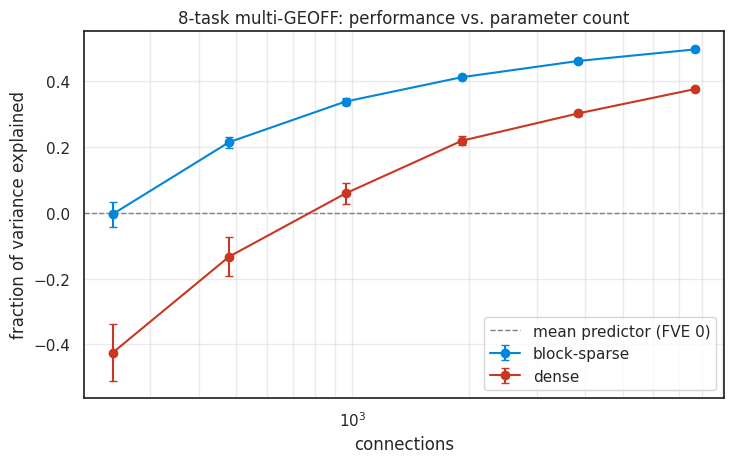

block_sparse
 target_params  hidden  value      fve   fve_ci  converged
           240       8  2.004 -0.00417  0.03795      False
           480      16  1.786   0.2143  0.01671       True
           960      32  1.662   0.3378  0.01013       True
          1920      64  1.588   0.4118 0.005841       True
          3840     128  1.539   0.4611 0.006231       True
          7680     256  1.504   0.4961 0.004322       True
dense
 target_params  hidden  value     fve   fve_ci  converged
           240       1  2.425 -0.4252  0.08584      False
           480       2  2.133 -0.1333  0.05924      False
           960       4  1.941 0.05866  0.03075       True
          1920       8  1.781  0.2188  0.01363       True
          3840      16  1.698  0.3018 0.007946       True
          7680      32  1.624  0.3756 0.006067       True


In [11]:
baselines = {}
for kind, spec in BASELINE_SPECS.items():
    summary = summarize_runs(
        cfgs, runs, spec.name, ['target_params'], FINAL_FRACTION, BASELINE_MSE)
    summary['fve'] = fve(summary['value'])
    summary['fve_ci'] = ci_halfwidth(summary['value_std'].fillna(0.0), N_SWEEP_SEEDS)
    summary['hidden'] = [baseline_hidden(kind, int(p)) for p in summary['target_params']]
    baselines[kind] = summary.sort_values('target_params')

plt.figure(figsize=(7.5, 4.8))
ax = plt.gca()
for color, (kind, summary) in zip(get_color_palette(n=2), baselines.items()):
    ax.errorbar(summary['target_params'], summary['fve'], yerr=summary['fve_ci'],
                marker='o', capsize=3, color=color, label=BASELINE_SPECS[kind].label)
ax.axhline(0.0, ls='--', c='gray', lw=1, label='mean predictor (FVE 0)')
ax.set_xscale('log')
ax.set_xlabel('connections')
ax.set_ylabel('fraction of variance explained')
ax.set_title('8-task multi-GEOFF: performance vs. parameter count')
ax.grid(True, alpha=0.4, which='both')
ax.legend()
plt.tight_layout()
plt.show()

for kind, summary in baselines.items():
    print(kind)
    print(summary[['target_params', 'hidden', 'value', 'fve', 'fve_ci', 'converged']]
          .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

### The connection budget

Experiment 3 gets roughly the smallest parameter count at which block-sparse performs well, and no
more — the point of the experiment is to find a good structure under a real constraint, and a
generous budget would let a bad structure look fine. "Performs well" is read as *within
`BUDGET_TOLERANCE` FVE of block-sparse's best point on the curve above*.

In [12]:
bs = baselines['block_sparse']
good = bs[bs['fve'] >= bs['fve'].max() - BUDGET_TOLERANCE]
suggested = int(good['target_params'].min())
print(f"block-sparse best FVE {bs['fve'].max():.4f}; smallest count within "
      f"{BUDGET_TOLERANCE} of it: {suggested}")

block-sparse best FVE 0.4961; smallest count within 0.02 of it: 7680


In [13]:
# Read off the curve above. Pinned as a constant rather than computed, so the sweep identities below
# are stable across re-runs — but flag it loudly if the data stops agreeing.
BUDGET = 1920
if BUDGET != suggested:
    print(f'WARNING: BUDGET is pinned at {BUDGET} but the data now suggests {suggested}. '
          'Re-read the curve above before trusting the Experiment 3 results.')
BUDGET_HIDDEN = baseline_hidden('block_sparse', BUDGET)
print(f'BUDGET = {BUDGET} connections '
      f'(block-sparse spends this on {BUDGET_HIDDEN} hidden units, '
      f'{BUDGET_HIDDEN // N_TASKS} per task; Experiment 3 uses {N_HIDDEN})')

BUDGET = 1920 connections (block-sparse spends this on 64 hidden units, 8 per task; Experiment 3 uses 64)


# Experiment 3a — static initial structure

The initialization held fixed: each hidden unit with exactly one outgoing connection to a random
output, and the rest of the budget spread evenly over all hidden and output units as random input
connections. Nothing about this structure knows the task decomposition, so it should be poor — that
is the point. It is the control that says how much of 3b's performance comes from *changing* the
connectivity rather than from the budget and the optimizer.

Two reference runs are added alongside it, at the same budget, the same meta step-size and the same
L1 penalty: block-sparse (close to an upper bound) and dense (the lower bound). Those two lines are
the scale for every 3b figure.

In [14]:
EXP3_STRUCTURE = structure_fn('exp3', BUDGET)

MAIN_SPECS = {
    'exp3a': ExpSpec(name='exp3a_static', label='3a — static initial structure',
                     fn=lambda n_seeds, n_steps, meta_lr, l1: run_config(
                         EXP3_STRUCTURE, meta_lr, n_seeds, n_steps, l1=l1)),
    'block_sparse': ExpSpec(name='ref_block_sparse', label='block-sparse (same budget + L1)',
                            fn=lambda n_seeds, n_steps, meta_lr, l1: run_config(
                                structure_fn('block_sparse', BUDGET), meta_lr, n_seeds, n_steps,
                                l1=l1)),
    'dense': ExpSpec(name='ref_dense', label='dense (same budget + L1)',
                     fn=lambda n_seeds, n_steps, meta_lr, l1: run_config(
                         structure_fn('dense', BUDGET), meta_lr, n_seeds, n_steps, l1=l1)),
}

for spec in MAIN_SPECS.values():
    run_spec_sweep(spec, {'meta_lr': META_LR, 'l1': L1_COEFF}, N_MAIN_SEEDS)

cfgs, runs = load_sweep_data()
traces = {key: load_traces(DATA_DIR, spec.name) for key, spec in MAIN_SPECS.items()}

[I 2026-07-31 12:54:21,562] Using an existing study with name 'multi-geoff-experiment-3/exp3a_static' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: ca61948603d34ae1858f5aebff9f0ef1.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.
[I 2026-07-31 12:54:21,702] Using an existing study with name 'multi-geoff-experiment-3/ref_block_sparse' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 0e8cadcffcda42ddb9567a3817f3910c.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.
[I 2026-07-31 12:54:21,842] Using an existing study with name 'multi-geoff-experiment-3/ref_dense' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 31c422aea45e402d9317dcd4c6280161.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


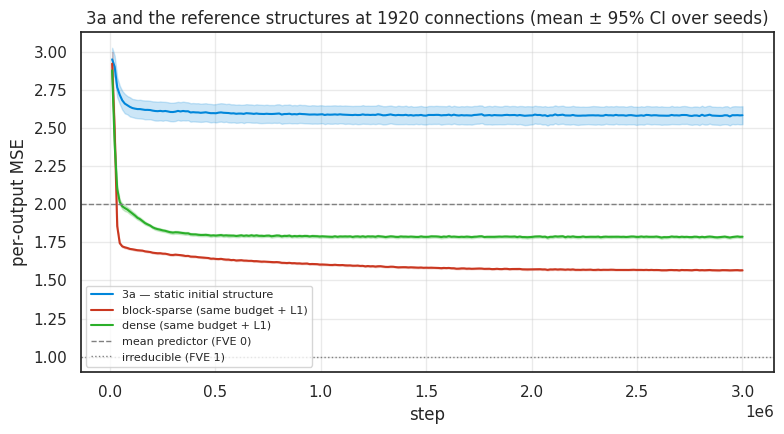

In [15]:
plt.figure(figsize=(8, 4.5))
ax = plt.gca()
for color, (key, spec) in zip(get_color_palette(n=len(MAIN_SPECS)), MAIN_SPECS.items()):
    plot_learning_curve(runs, spec.name, label=spec.label, color=color, ax=ax,
                        n_seeds=N_MAIN_SEEDS)
ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor (FVE 0)')
ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible (FVE 1)')
ax.set_ylabel('per-output MSE')
ax.set_title(f'3a and the reference structures at {BUDGET} connections '
             '(mean ± 95% CI over seeds)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

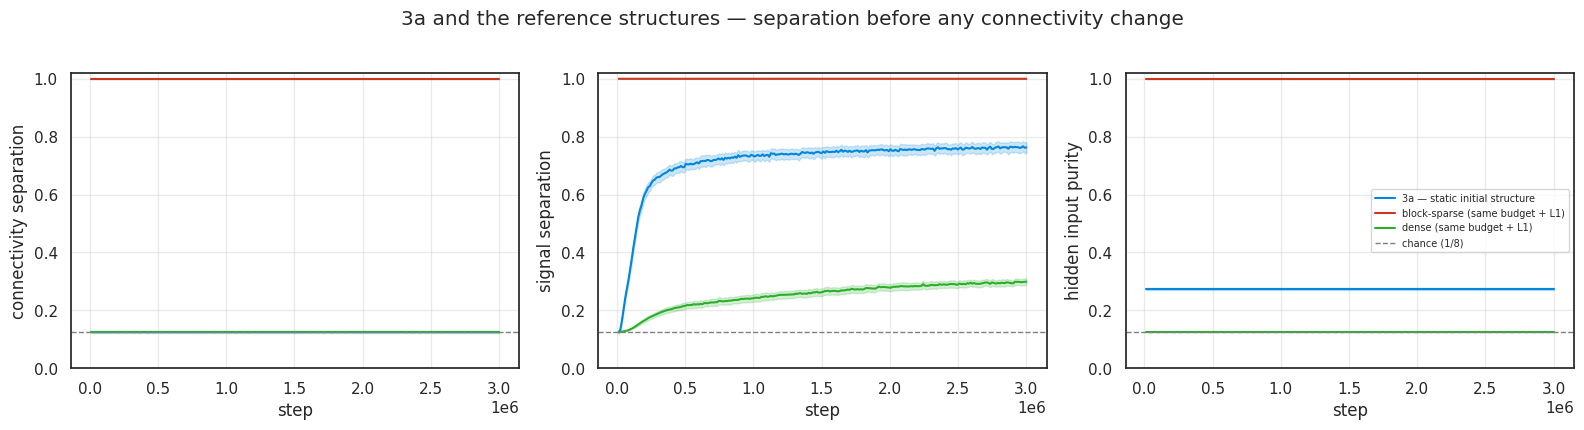

                            run   MSE    FVE  conn. sep.  signal sep.  purity  in/hidden  out/hidden  dead hidden  connections  prunes/step
  3a — static initial structure 2.581 -0.581      0.1257       0.7625   0.274      12.89           1            0         1920            0
block-sparse (same budget + L1) 1.567 0.4326           1            1       1         20          10            0         1920            0
       dense (same budget + L1) 1.785 0.2148       0.125       0.2957   0.125        160          80            0         1920            0


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
labels = {key: MAIN_SPECS[key].label for key in MAIN_SPECS}
named = {labels[key]: traces[key] for key in MAIN_SPECS}
for ax, (key, ylabel, reference) in zip(axes, [
        ('connectivity_separation', 'connectivity separation', 1.0 / N_TASKS),
        ('signal_separation', 'signal separation', 1.0 / N_TASKS),
        ('hidden_input_purity', 'hidden input purity', 1.0 / N_TASKS)]):
    plot_snapshot_metric(named, key, ylabel, ax=ax, hline=reference,
                         hline_label=f'chance (1/{N_TASKS})')
    ax.set_ylim(0, 1.02)
axes[-1].legend(fontsize=7, loc='best')
# Connectivity separation and purity are functions of the masks alone, so they are flat by
# construction here — they are drawn to calibrate the panels 3b reuses. Signal separation is not:
# it weights each path by its weights, so it moves as the optimizer suppresses cross-task paths,
# and it is the one line in this figure that says anything about 3a's training.
plt.suptitle('3a and the reference structures — separation before any connectivity change', y=1.02)
plt.tight_layout()
plt.show()

print(pd.DataFrame([summary_row(spec.label, traces[key], runs, spec.name)
                    for key, spec in MAIN_SPECS.items()])
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

# Experiment 3b — online connectivity changes

Now the connectivity changes while training. Every step, each hidden and output unit tests each of
its incoming connections: **prune when the weight crossed zero this step and its gradient trace h is
jitter-sized** (`h² < α v / 4`, with v the unit's squared-error trace). Each pruned connection frees
one slot, and generation immediately spends it — a destination uniformly over all hidden and output
units, then a source uniformly over the units in earlier layers it is not already connected to. The
new connection starts at weight 0 with a 1e-6 step-size.

Three versions, in the plan's order:

* **base** — gradient masking: no error flows from an output unit back into a hidden unit except
  through the hidden→output connections created at initialization, which are correspondingly exempt
  from pruning. This has no effect until new hidden→output connections start appearing.
* **Variant 1** — no special initial connections: they can be pruned like any other, and every
  connection carries gradient.
* **Variant 2** — Variant 1 plus a maturity gate on generation: a new connection's source must be a
  **mature** unit (input units always are; a hidden unit matures when its first outgoing connection
  matures, per Experiment 2's stage definitions).

In [17]:
DYNAMIC_SPECS = {
    'base': ExpSpec(name='exp3b_base', label='3b base (masked gradients)',
                    fn=lambda n_seeds, n_steps, meta_lr, l1: run_config(
                        EXP3_STRUCTURE, meta_lr, n_seeds, n_steps, l1=l1,
                        restructure=True, protect=True)),
    'variant1': ExpSpec(name='exp3b_variant1', label='3b variant 1 (no special connections)',
                        fn=lambda n_seeds, n_steps, meta_lr, l1: run_config(
                            EXP3_STRUCTURE, meta_lr, n_seeds, n_steps, l1=l1, restructure=True)),
    'variant2': ExpSpec(name='exp3b_variant2', label='3b variant 2 (mature sources only)',
                        fn=lambda n_seeds, n_steps, meta_lr, l1: run_config(
                            EXP3_STRUCTURE, meta_lr, n_seeds, n_steps, l1=l1, restructure=True,
                            require_mature_source=True)),
}

for spec in DYNAMIC_SPECS.values():
    run_spec_sweep(spec, {'meta_lr': META_LR, 'l1': L1_COEFF}, N_MAIN_SEEDS)

cfgs, runs = load_sweep_data()
traces.update({key: load_traces(DATA_DIR, spec.name) for key, spec in DYNAMIC_SPECS.items()})

ALL_SPECS = {**MAIN_SPECS, **DYNAMIC_SPECS}
ALL_TRACES = {ALL_SPECS[key].label: traces[key] for key in ALL_SPECS}

[I 2026-07-31 12:54:22,732] Using an existing study with name 'multi-geoff-experiment-3/exp3b_base' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 48e146cae4d849e580381d192e8838d4.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.
[I 2026-07-31 12:54:22,861] Using an existing study with name 'multi-geoff-experiment-3/exp3b_variant1' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 2cfe9492ecce4de785287b524fc319f7.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.
[I 2026-07-31 12:54:22,985] Using an existing study with name 'multi-geoff-experiment-3/exp3b_variant2' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 167efcc65df740a8a982f834897d9a57.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


### Did the budget hold?

Before reading anything else: the connection count must stay at the budget. It is exactly
`BUDGET - deficit` at every step, so a non-trivial deficit means `GEN_CAP` saturated or proposals
kept colliding, and the run silently trained a smaller network than intended.

In [18]:
for key, spec in DYNAMIC_SPECS.items():
    t = traces[key]
    print(f'{spec.label:42s} connections {final_value(t, "n_connections"):8.1f} / {BUDGET}   '
          f'mean deficit {np.asarray(t["deficit"]).mean():7.3f}   '
          f'worst single step {np.asarray(t["max_deficit"]).max():6.0f}   '
          f'prunes/step {final_value(t, "prune_rate"):.3f}')
    assert final_value(t, 'n_connections') > 0.99 * BUDGET, \
        f'{spec.label}: the network lost more than 1% of its connections — raise GEN_CAP'

3b base (masked gradients)                 connections   1920.0 / 1920   mean deficit   0.000   worst single step      2   prunes/step 0.020
3b variant 1 (no special connections)      connections   1920.0 / 1920   mean deficit   0.000   worst single step      1   prunes/step 0.001
3b variant 2 (mature sources only)         connections   1920.0 / 1920   mean deficit   0.000   worst single step      1   prunes/step 0.000


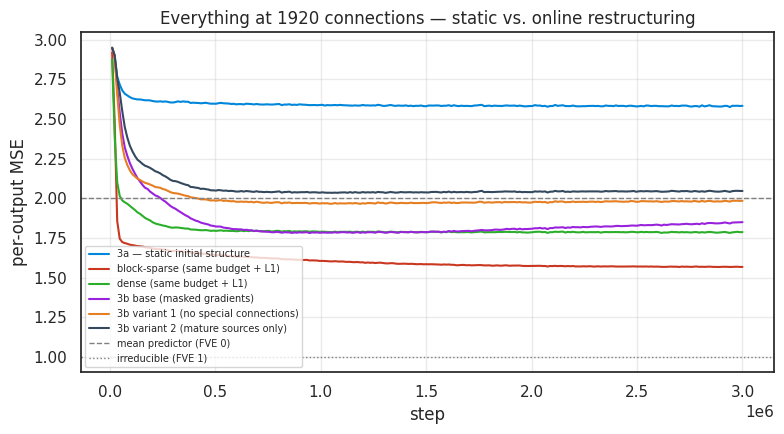

In [19]:
plt.figure(figsize=(8, 4.5))
ax = plt.gca()
for color, (key, spec) in zip(get_color_palette(n=len(ALL_SPECS)), ALL_SPECS.items()):
    plot_learning_curve(runs, spec.name, label=spec.label, color=color, ax=ax,
                        n_seeds=N_MAIN_SEEDS, show_ci=False)
ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor (FVE 0)')
ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible (FVE 1)')
ax.set_ylabel('per-output MSE')
ax.set_title(f'Everything at {BUDGET} connections — static vs. online restructuring')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

### Structure over time

The question these figures answer: does restructuring actually walk the network toward one
subnetwork per task? Connectivity separation counts paths from each output back to the inputs and
asks what fraction land on its own subtask; signal separation weights each path by the product of
its weights; hidden input purity looks at the hidden layer alone, so it separates "the outputs
happen to read clean paths" from "the hidden units have specialized". Chance is 1/8 for all three,
and block-sparse is 1.

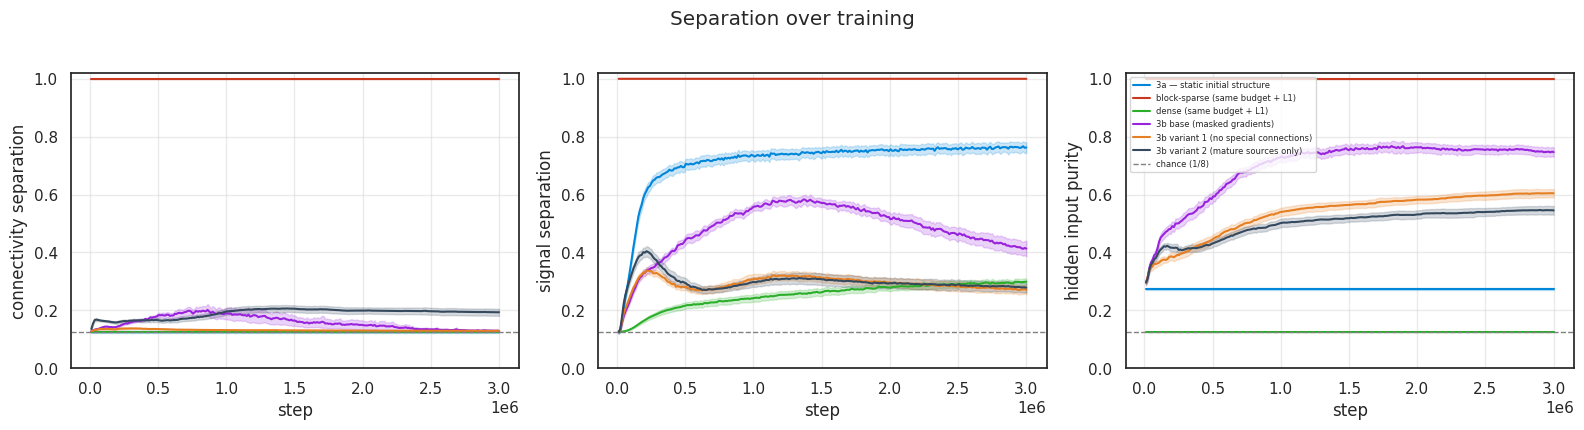

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (key, ylabel) in zip(axes, [
        ('connectivity_separation', 'connectivity separation'),
        ('signal_separation', 'signal separation'),
        ('hidden_input_purity', 'hidden input purity')]):
    plot_snapshot_metric(ALL_TRACES, key, ylabel, ax=ax, hline=1.0 / N_TASKS,
                         hline_label=f'chance (1/{N_TASKS})')
    ax.set_ylim(0, 1.02)
axes[-1].legend(fontsize=6, loc='best')
plt.suptitle('Separation over training', y=1.02)
plt.tight_layout()
plt.show()

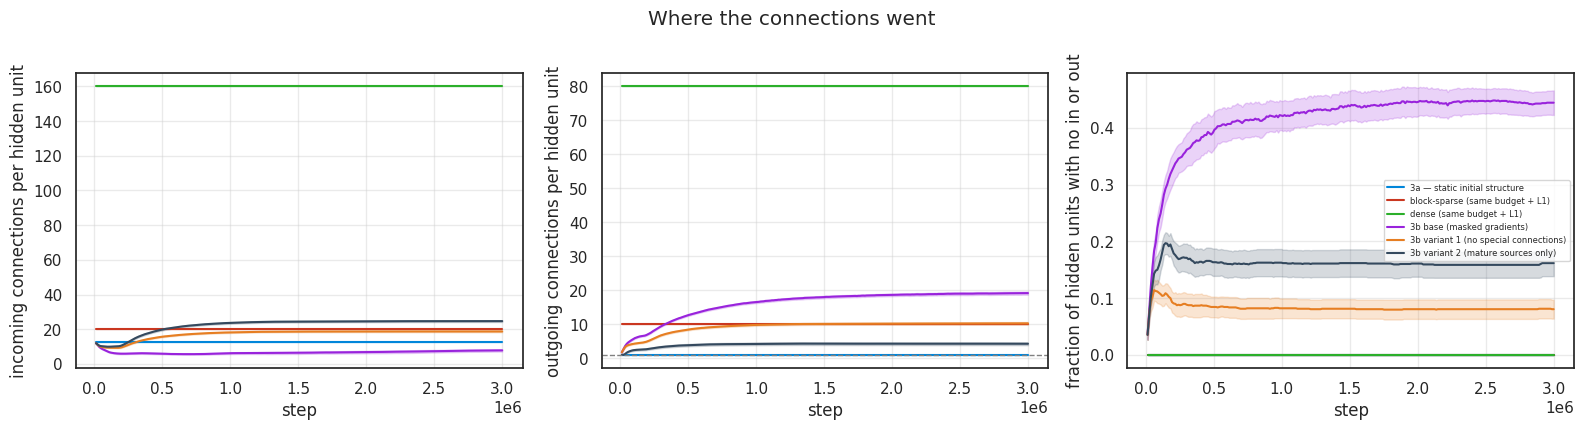

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_snapshot_metric(ALL_TRACES, 'hidden_incoming', 'incoming connections per hidden unit',
                     ax=axes[0])
plot_snapshot_metric(ALL_TRACES, 'hidden_outgoing', 'outgoing connections per hidden unit',
                     ax=axes[1], hline=1.0, hline_label='initialization (1)')
plot_snapshot_metric(ALL_TRACES, 'dead_hidden_fraction',
                     'fraction of hidden units with no in or out', ax=axes[2])
axes[-1].legend(fontsize=6, loc='best')
plt.suptitle('Where the connections went', y=1.02)
plt.tight_layout()
plt.show()

### Turnover and the stages

`prune_rate` is the number of connections replaced per step, which says whether the structure is
converging or thrashing: a rate that stays high means connections are being recycled faster than
they can prove themselves. The stage panel is the machinery Variant 2 gates on — with `growth` and
`mature` fractions near zero, Variant 2's maturity gate has nothing to select and it degenerates
into "generate from inputs only".

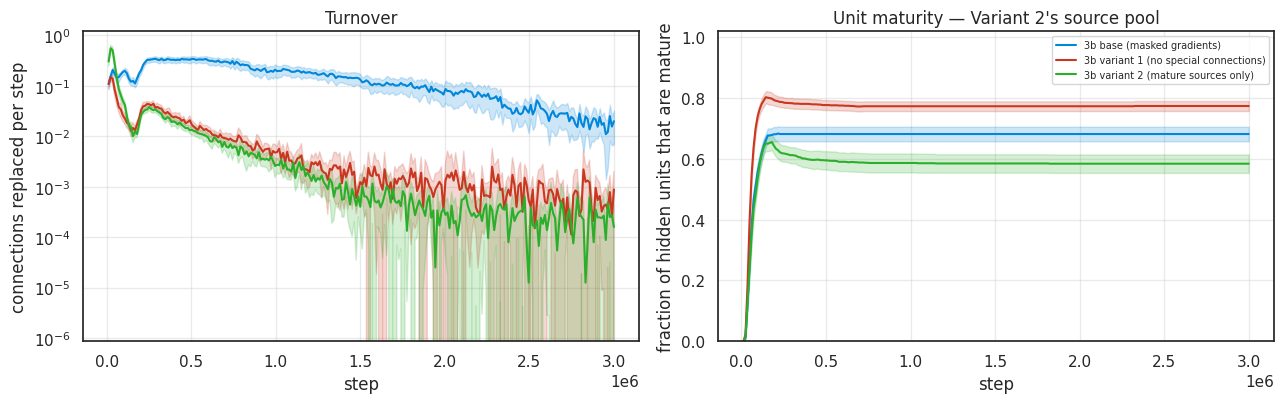

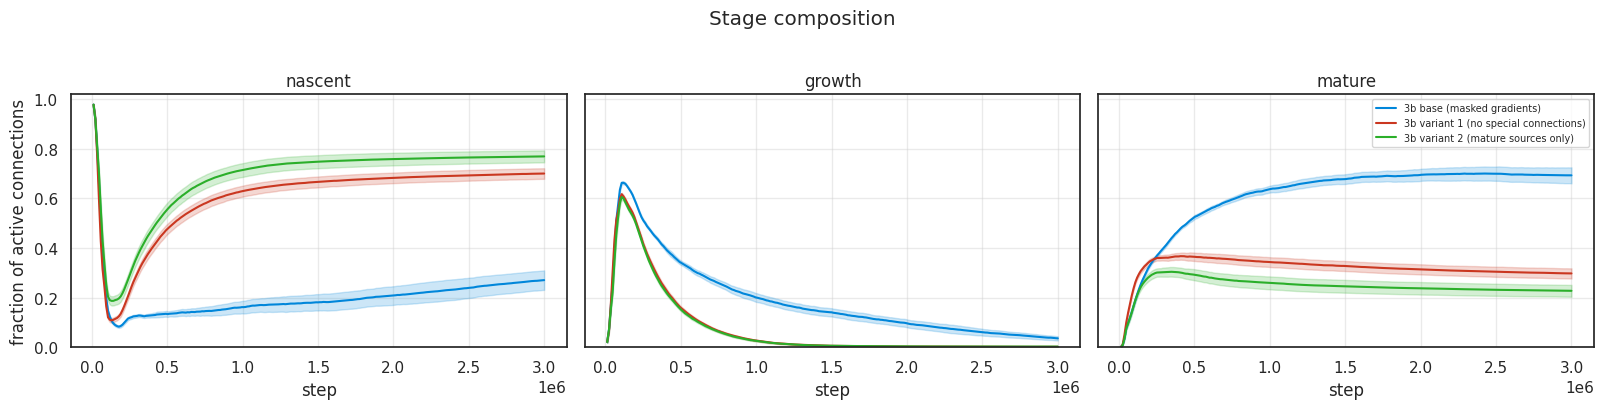

In [22]:
dynamic_traces = {DYNAMIC_SPECS[key].label: traces[key] for key in DYNAMIC_SPECS}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_snapshot_metric(dynamic_traces, 'prune_rate', 'connections replaced per step', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Turnover')
plot_snapshot_metric(dynamic_traces, 'mature_hidden_fraction',
                     'fraction of hidden units that are mature', ax=axes[1])
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Unit maturity — Variant 2's source pool")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(STAGE_NAMES), figsize=(5.4 * len(STAGE_NAMES), 4.0), sharey=True)
for ax, name in zip(axes, STAGE_NAMES):
    plot_snapshot_metric(dynamic_traces, f'fraction_{name}',
                         'fraction of active connections' if name == STAGE_NAMES[0] else '', ax=ax)
    ax.set_ylim(0, 1.02)
    ax.set_title(name)
axes[-1].legend(fontsize=7)
plt.suptitle('Stage composition', y=1.02)
plt.tight_layout()
plt.show()

### Summary

In [23]:
print(pd.DataFrame([summary_row(spec.label, traces[key], runs, spec.name)
                    for key, spec in ALL_SPECS.items()])
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

                                  run   MSE      FVE  conn. sep.  signal sep.  purity  in/hidden  out/hidden  dead hidden  connections  prunes/step
        3a — static initial structure 2.581   -0.581      0.1257       0.7625   0.274      12.89           1            0         1920            0
      block-sparse (same budget + L1) 1.567   0.4326           1            1       1         20          10            0         1920            0
             dense (same budget + L1) 1.785   0.2148       0.125       0.2957   0.125        160          80            0         1920            0
           3b base (masked gradients) 1.841   0.1585      0.1304       0.4265  0.7514       7.71       19.11       0.4438         1920      0.01998
3b variant 1 (no special connections) 1.981  0.01885      0.1292       0.2747  0.6038      18.72       10.26      0.08072         1920    0.0006462
   3b variant 2 (mature sources only) 2.044 -0.04379      0.1942       0.2821  0.5455      24.67       4.265    

## What to take from this

Read the figures against what the plan predicts:

* **3a should be poor** — it is a random structure with no knowledge of the task decomposition, and
  it sits between dense and block-sparse only because it is sparse, not because it is *right*. If
  3a is already close to block-sparse, the budget is too generous and the whole comparison is
  uninformative; go back to the baselines curve and pick a tighter one.
* **3b should beat 3a** and move the separation metrics up from chance. Performance alone is not
  enough: a run that lowers MSE while connectivity separation stays at 1/8 has found a *dense-ish*
  solution the optimizer can cope with, not the subnetwork decomposition the plan is after.
* **The variants are a sequence, not a competition.** The base version has the strongest crutch
  (gradient masking plus protected connections), Variant 1 removes it, Variant 2 tries to earn it
  back with the maturity gate. The interesting comparison is Variant 1 vs. Variant 2: if Variant 1
  degrades and Variant 2 recovers, the maturity rule is doing the work it was designed for.
* **Check the turnover before believing any of it.** A prune rate that never falls means the
  structure is being recycled faster than it can be evaluated, and the separation metrics are
  measuring noise. The same goes for the deficit check above — it is an assertion, not a plot,
  because a run that lost connections is not comparable to one that did not.

### The one dead end the rules allow, worth watching for in `dead_hidden_fraction`

**A hidden unit with no outgoing connections holds its incoming ones until it gets one back.** Its
backpropagated error is exactly zero, so its squared-error trace v decays to zero while L1 keeps its
h at a nonzero value, and the prune test `h² < α v / 4` can then never fire. Until something
reconnects it, those connections are budget doing no work. Variant 1 and 2 can reach this state; the
base version cannot, because its initial outgoing connection is protected from pruning.

The escape route is generation choosing that unit as the *source* of a new hidden→output connection,
after which error flows again and its incoming connections become prunable like any others. That is
why such a unit **counts as mature** here even though it has no outgoing connection whose stage
could be read: the alternative makes the state absorbing under Variant 2 — never a legal source, so
never an outgoing connection, so never mature — while generation keeps handing it fresh incoming
connections. Note this is a deliberate departure from `connection_stages.hidden_unit_stages`, which
reads the empty maximum as nascent; Experiment 2's structures never have such a unit, so the two
only disagree in the case Experiment 3 actually creates.

### Not implemented here, and why

* **The L1 penalty on the baselines.** The dense and block-sparse curves in the interlude are run
  without it, so they measure the architecture rather than the architecture plus the regularizer;
  the L1-matched versions at the chosen budget are in the 3a section instead.
* **Generation is capped per step** (`GEN_CAP`) and colliding proposals are refilled on later steps
  rather than resampled within the step. Both are visible in the deficit check; neither is the
  plan's literal one-at-a-time sampling, which is not expressible at a fixed shape inside `scan`.
* **Experiment 2's validation of the stage rule** is a separate notebook. This one tracks the stages
  and uses them in Variant 2 regardless, so if Experiment 2 revises the thresholds, Variant 2 has to
  be re-run.